# **Analyse des dépenses au sein de l'assurance maladie**
## **Objectif :**
- Etudier les fluctuations des dépenses de la caisse primaire des assurances maladie
- Définir les secteurs et raisons des dépenses les plus présents

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**

In [3]:
path = "../../data/silver/depenses_timeseries_features_2015_2025.csv"
path_union = "../../data/silver/depenses_timeseries_features_union_2015_2025.csv"

df = pd.read_csv(path, delimiter=";")
df_union = pd.read_csv(path_union, delimiter=";")

In [4]:
df.head()

,date,Autres,Cures thermales,Dentistes,Généralistes,Indemnités journalières (IJ),Infirmières,Kinésithérapeutes,Laboratoires,Liste des produits et prestations (LPP),...,Orthoptistes,Pédicures,Remboursement de soins à l'étranger,Sages-femmes,Spécialistes,Total,Transports,dont IJ maladie,"dont autres médicaments (franchises, Rosp, gardes pharmacies …)",dont rétrocession hospitalière
0,2015-01-01,2.510100e+06,1.356945e+07,2.183601e+08,7.455998e+08,7.783985e+08,4.173681e+08,2.489425e+08,2.262580e+08,4.094080e+08,...,5.171915e+06,1.385455e+06,1.312802e+07,1.675119e+07,7.813881e+08,6.028024e+09,2.855157e+08,5.540391e+08,7.731469e+07,2.208109e+08
1,2015-02-01,4.016426e+06,1.625153e+07,2.176725e+08,4.615647e+08,7.746956e+08,4.177061e+08,2.474070e+08,2.265094e+08,3.972281e+08,...,4.949724e+06,1.386585e+06,1.306531e+07,1.657797e+07,7.503774e+08,5.561082e+09,2.781105e+08,5.552457e+08,-4.415430e+07,2.236308e+08
2,2015-03-01,5.051655e+06,1.807191e+07,2.341007e+08,4.610908e+08,7.790071e+08,4.205450e+08,2.619559e+08,2.365197e+08,4.251686e+08,...,5.481767e+06,1.505579e+06,1.334480e+07,1.780274e+07,7.793177e+08,5.705020e+09,2.902507e+08,5.549771e+08,-4.332721e+07,2.298866e+08
3,2015-04-01,6.788215e+06,1.768251e+07,2.253043e+08,4.526270e+08,7.773361e+08,4.242497e+08,2.571210e+08,2.392123e+08,4.269860e+08,...,5.260044e+06,1.445524e+06,1.325068e+07,1.769039e+07,7.756445e+08,5.659840e+09,2.875983e+08,5.578931e+08,-4.298638e+07,2.213635e+08
4,2015-05-01,4.282449e+06,1.937152e+07,2.178408e+08,4.499772e+08,7.723644e+08,4.299485e+08,2.461182e+08,2.364123e+08,4.033060e+08,...,5.348870e+06,1.460632e+06,1.325723e+07,1.774658e+07,7.580863e+08,5.567404e+09,2.845245e+08,5.475540e+08,-4.314752e+07,2.012937e+08


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 22 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   date                                                             130 non-null    object 
 1   Autres                                                           130 non-null    float64
 2   Cures thermales                                                  130 non-null    float64
 3   Dentistes                                                        130 non-null    float64
 4   Généralistes                                                     130 non-null    float64
 5   Indemnités journalières (IJ)                                     130 non-null    float64
 6   Infirmières                                                      130 non-null    float64
 7   Kinésithérapeutes                           

In [6]:
df_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 31 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   date                                                             130 non-null    object 
 1   Autres                                                           130 non-null    float64
 2   Centres de santé                                                 84 non-null     float64
 3   Cures thermales                                                  130 non-null    float64
 4   Dentistes                                                        130 non-null    float64
 5   Généralistes                                                     130 non-null    float64
 6   Indemnités journalières (IJ)                                     130 non-null    float64
 7   Infirmières                                 

In [7]:
df_cols = df.columns.tolist()
df_cols_keep = [col for col in df_cols if col not in ["date", "date_annee", "date_mois"]]

df_union_cols = df_union.columns.tolist()
df_union_cols_keep = [col for col in df_union_cols if col not in ["date", "date_annee", "date_mois"]]

## **Evolution des dépenses totales de la CPAM**

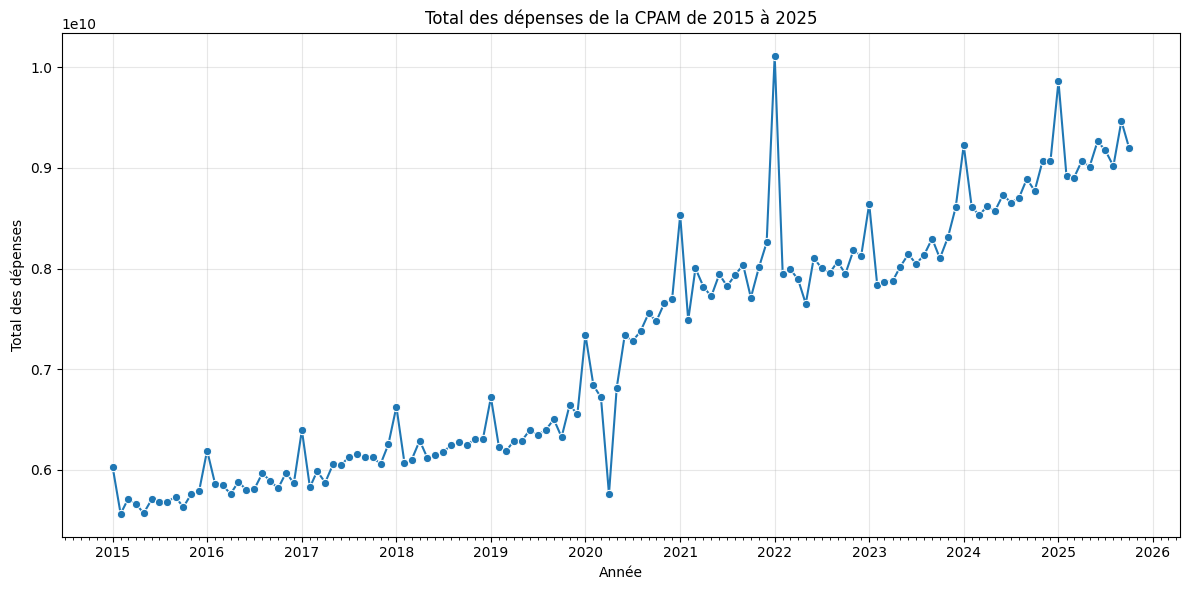

In [8]:
import matplotlib.dates as mdates

def plot_total_depenses(df: pd.DataFrame) -> None:
    """
    Plot des dépenses mensuelles avec affichage des années en abscisse.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=df, x="date", y="Total", marker="o", ax=ax)

    # Afficher uniquement les années sur l'axe X
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())  # garde la granularité mensuelle

    ax.set_title("Total des dépenses de la CPAM de 2015 à 2025")
    ax.set_xlabel("Année")
    ax.set_ylabel("Total des dépenses")
    ax.grid(True, which="major", alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_total_depenses(df)

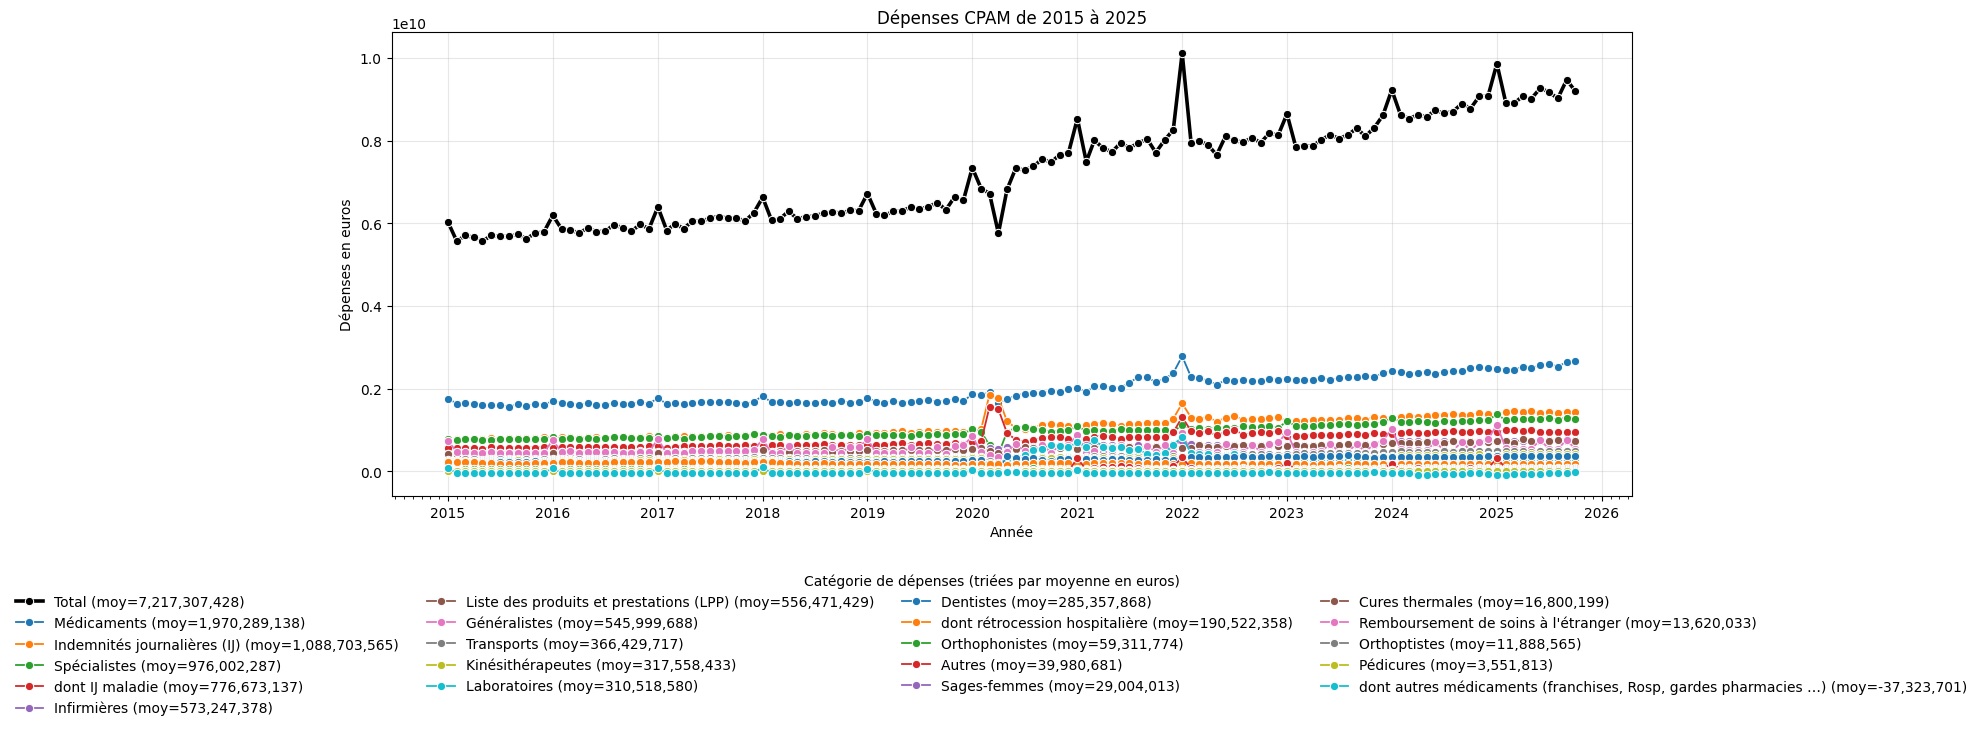

In [9]:
def plot_total_depenses_segmented(df: pd.DataFrame, isUnion: bool = False) -> None:
    """Trace les dépenses mensuelles par poste avec légende triée par moyenne.

    Le tracé utilise les colonnes globales définies en amont:
    - `df_union_cols_keep` si `isUnion` est `False`
    - `df_cols_keep` si `isUnion` est `True`

    Args:
        df: DataFrame source contenant `date` et des colonnes numériques.
        isUnion: Sélection de la liste globale de colonnes à tracer.

    Returns:
        None. Affiche un graphique.
    """
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d = d.dropna(subset=["date"]).sort_values("date")

    cols_to_plot = df_union_cols_keep if not isUnion else df_cols_keep
    cols_to_plot = [c for c in cols_to_plot if c in d.columns]

    if not cols_to_plot:
        raise ValueError("Aucune colonne à tracer trouvée.")

    mean_by_col = d[cols_to_plot].mean(numeric_only=True).dropna().sort_values(ascending=False)
    ordered_cols = mean_by_col.index.tolist()

    fig, ax = plt.subplots(figsize=(16, 8))

    for col in ordered_cols:
        is_total = col == "Total"
        sns.lineplot(
            data=d,
            x="date",
            y=col,
            ax=ax,
            marker="o",
            linewidth=2.6 if is_total else 1.3,
            color="black" if is_total else None,
            label=f"{col} (moy={mean_by_col[col]:,.0f})",
        )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.set_title("Dépenses CPAM de 2015 à 2025")
    ax.set_xlabel("Année")
    ax.set_ylabel("Dépenses en euros")
    ax.grid(True, which="major", alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    lookup = dict(zip(labels, handles))
    ordered_labels = [f"{c} (moy={mean_by_col[c]:,.0f})" for c in ordered_cols]
    ordered_handles = [lookup[l] for l in ordered_labels if l in lookup]

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    fig.legend(
        ordered_handles,
        ordered_labels,
        title="Catégorie de dépenses (triées par moyenne en euros)",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        frameon=False,
    )

    fig.subplots_adjust(bottom=0.30)
    plt.show()

plot_total_depenses_segmented(df, isUnion=False)

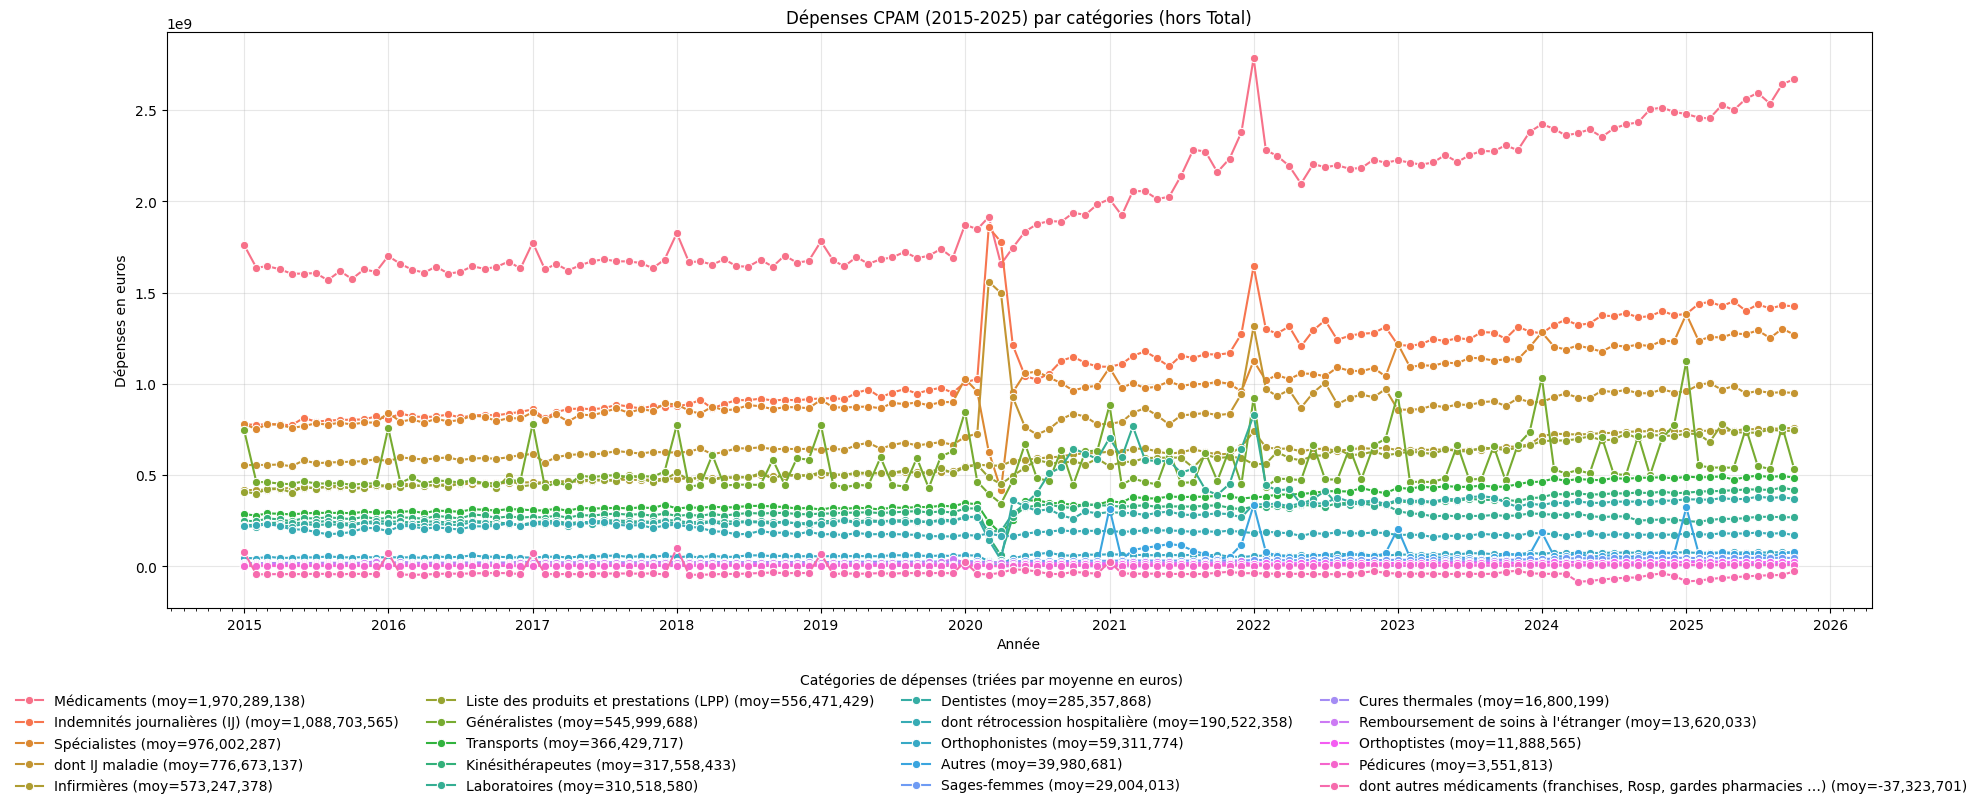

In [10]:
def plot_depenses_segmented(df: pd.DataFrame) -> None:
    """Plot des dépenses mensuelles par catégories (hors Total), triées par moyenne.

    Args:
        df: DataFrame avec colonne `date` et colonnes de dépenses.

    Returns:
        None. Affiche un graphique.
    """
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data = data.dropna(subset=["date"]).sort_values("date")

    categories_depenses = [c for c in df_cols_keep if c in data.columns and c != "Total"]
    if not categories_depenses:
        raise ValueError("Aucune catégorie de dépenses à tracer (hors Total).")

    mean_by_category = (
        data[categories_depenses]
        .mean(numeric_only=True)
        .dropna()
        .sort_values(ascending=False)
    )
    categories_tries = mean_by_category.index.tolist()

    data_long = data.melt(
        id_vars="date",
        value_vars=categories_tries,
        var_name="categories_depenses",
        value_name="depenses",
    )

    fig, ax = plt.subplots(figsize=(22, 9))
    sns.lineplot(
        data=data_long,
        x="date",
        y="depenses",
        hue="categories_depenses",
        hue_order=categories_tries,
        marker="o",
        linewidth=1.5,
        ax=ax,
    )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.set_title("Dépenses CPAM (2015-2025) par catégories (hors Total)")
    ax.set_xlabel("Année")
    ax.set_ylabel("Dépenses en euros")
    ax.grid(True, which="major", alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    labels_with_mean = [f"{lab} (moy={mean_by_category[lab]:,.0f})" for lab in labels]

    # Retire la légende de l'axe
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Ajoute la légende sous la figure
    fig.legend(
        handles,
        labels_with_mean,
        title="Catégories de dépenses (triées par moyenne en euros)",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
    )

    # Réserve de l'espace pour la légende
    fig.subplots_adjust(bottom=0.24)
    plt.show()

plot_depenses_segmented(df)

In [11]:
def generate_pourcentages(df: pd.DataFrame) -> pd.DataFrame:
    """Génère un DataFrame avec les pourcentages de chaque catégorie de dépenses par rapport au total.

    Args:
        df: DataFrame d'origine contenant une colonne 'Total' et des colonnes de catégories de dépenses.

    Returns:
        DataFrame avec les mêmes colonnes que df_cols_keep, mais avec des valeurs en pourcentage du total.
    """
    df_pourcentages = df.copy()
    for col in df_cols_keep:
        if col != "Total" and col in df_pourcentages.columns:
            df_pourcentages[col] = (df_pourcentages[col] / df_pourcentages["Total"]) * 100
    return df_pourcentages

df_pourcentages = generate_pourcentages(df)

In [ ]:
def plot_pourcentages(df: pd.DataFrame) -> None:
    """Trace un graphique annuel en barres empilees avec une courbe du total.

    Le rendu vise un style proche de l'exemple fourni.
    """
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data = data.dropna(subset=["date"]).sort_values("date")

    categories_depenses = [c for c in df_cols_keep if c in data.columns and c != "Total"]
    if not categories_depenses:
        raise ValueError("Aucune categorie de depenses a tracer (hors Total).")

    data["annee"] = data["date"].dt.year

    mean_by_category = (
        data[categories_depenses]
        .mean(numeric_only=True)
        .dropna()
        .sort_values(ascending=False)
    )
    categories_tries = mean_by_category.index.tolist()

    yearly_pct = (
        data.groupby("annee", as_index=True)[categories_tries]
        .mean(numeric_only=True)
        .fillna(0)
    )

    total_series = None
    if "Total" in data.columns:
        total_series = data.groupby("annee", as_index=True)["Total"].mean(numeric_only=True)

    fig, ax = plt.subplots(figsize=(16, 9))
    colors = sns.color_palette("Set2", n_colors=len(categories_tries))

    bottom = pd.Series(0.0, index=yearly_pct.index)
    bar_handles = []
    for color, category in zip(colors, categories_tries):
        bars = ax.bar(
            yearly_pct.index,
            yearly_pct[category],
            bottom=bottom,
            width=0.75,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            label=f"{category} ({mean_by_category[category]:.1f}%)",
        )
        bar_handles.append(bars[0])
        bottom = bottom.add(yearly_pct[category], fill_value=0)

    ax.set_xlim(yearly_pct.index.min() - 0.7, yearly_pct.index.max() + 0.7)
    ax.set_xticks(yearly_pct.index)
    ax.set_xlabel("Annee")
    ax.set_ylabel("Part des categories dans le total (%)")
    ax.set_title("Repartition annuelle des categories de depenses")
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    if total_series is not None:
        ax2 = ax.twinx()
        ax2.plot(
            total_series.index,
            total_series.values,
            color="black",
            linewidth=2.2,
            marker="o",
            markersize=4,
            label="Total moyen",
        )
        ax2.set_ylabel("Total moyen")
        line_handles, line_labels = ax2.get_legend_handles_labels()
    else:
        line_handles, line_labels = [], []

    fig.legend(
        bar_handles + line_handles,
        [h.get_label() for h in bar_handles] + line_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
        title="Categories",
    )

    fig.subplots_adjust(bottom=0.22)
    plt.show()

plot_pourcentages(df_pourcentages)